# SPARC-4 products
***

This notebook shows an example for viewing and accessing the SPARC4 data products.

* Eder Martioli, LNA 18 Apr 2024
* Fernando Falkenberg INPE 09 Oct 2025

In [1]:
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sparc4.product_plots as s4plt
import sparc4.pipeline_lib as s4pipelib

### Set paths to example files 
Below we set the paths to the files, which are sparc4-pipeline products.

In [3]:
path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '4'

In [4]:
db_example = f'{path}{date}/sparc4acs{channel}/{date}_sparc4acs{channel}_db.csv'
# Esse arquivo é uma tabela que contém informações de todas as imagens daquela noite, naquele canal, por exemplo, diretório, tempo de exposição, posição da lâmina, etc.

phot_lightcurve_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_S+N_lc.fits'
# Esse arquivo contém várias tabelas dentro dele, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela, estão informações de cada uma das fontes detectadas pelo pipeline, para cada imagem daquele objeto, por exemplo, RA, Dec, magnitude (com seu erro), fwhm, etc.

polar_stack_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_stack.fits'
# Esse arquivo contém várias tabelas dentro dele, duas para cada abertura em que os dados do objeto foram processados (sendo uma para o feixe ordinário e a outra para o feixe extraordinário). Cada tabela contém uma linha para cada fonte identificada pelo pipeline. Para cada linha, existem informações como RA, Dec, magnitude (com seu erro), fwhm, etc. É uma versão do arquivo logo acima, só que para apenas uma imagem stack.

polar_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_polar.fits'
# Esse arquivo contém várias tabelas, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela existe uma linha para cada fonte detectada pelo pipeline. Em cada linha estão os resultados da polarimetria para aquela fonte, por exemplo, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... Além disso, também estão as contagens para cada posição de lâmina, para cada fonte, para cada imagem, com seus erros. É nesse arquivo que estão os dados importantes.

polar_time_series_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_ts.fits'
# Esse arquivo contém uma tabela com os dados da série temporal polarimétrica das fontes detectadas pelo pipeline, por exemplo, RA, Dec, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... O resultado aqui é para cada conjunto de uma medida polarimétrica.

# DB product example
***
In this simple example, we just read the database created by the `sparc4-pipeline` and print it as a pandas table. It's an easy way to quickly access the log of observations.

In [5]:
db = ascii.read(db_example)
pd.DataFrame(np.array(db))

,FILE,DATE-OBS,EXPTIME,RA,DEC,OBJECT,OBSTYPE,INSTMODE,CHANNEL,VBIN,...,VCLKAMP,CCDSERN,PREAMP,READRATE,EMMODE,EMGAIN,WPPOS,WPSEL,CALW,ASEL
0,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:08.407000,0.05,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,1,L2,None,True
1,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:11.139000,0.05,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,2,L2,None,True
2,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:13.740000,0.05,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,3,L2,None,True
3,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:16.418000,0.05,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,4,L2,None,True
4,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:19.038000,0.05,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,5,L2,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2375,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-07T09:10:12.779827,0.30,22:17:55.38,-08:21:03.70,DOMEFLAT,FLAT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,16,L4,None,True
2376,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-07T09:10:14.199890,0.30,22:17:55.38,-08:21:03.70,DOMEFLAT,FLAT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,16,L4,None,True
2377,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-07T09:10:15.619952,0.30,22:17:55.38,-08:21:03.70,DOMEFLAT,FLAT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,16,L4,None,True
2378,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-07T09:10:17.040015,0.30,22:17:55.38,-08:21:03.70,DOMEFLAT,FLAT,POLAR,4,1,...,Normal,9917,Gain 2,1.0,Conventional,2,16,L4,None,True


# POLAR products example
***
In this example we show how to work with the polarimetric products of SPARC4

We start by reading the science image FITS file and showing its information. 

In [6]:
hdul = fits.open(polar_stack_example)
hdul.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250706/sparc4acs4/20250706_s4c4_Gain2_1.0_Conventional_2_V2400Oph_POLAR_L4_stack.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     167   (1024, 1024)   float64   
  1  CATALOG_POL_S_AP005    1 TableHDU        51   271R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  2  CATALOG_POL_N_AP005    1 TableHDU        51   271R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  3  CATALOG_POL_S_AP008    1 TableHDU        51   271R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  4  CATALOG_POL_N_AP008    1 TableHDU        51   271R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  5  CATALOG_POL_S_AP010    1 TableHDU        51   271R x 13C   [I11, D2

Then we plot the science frame using the `sparc4.product_plots` library

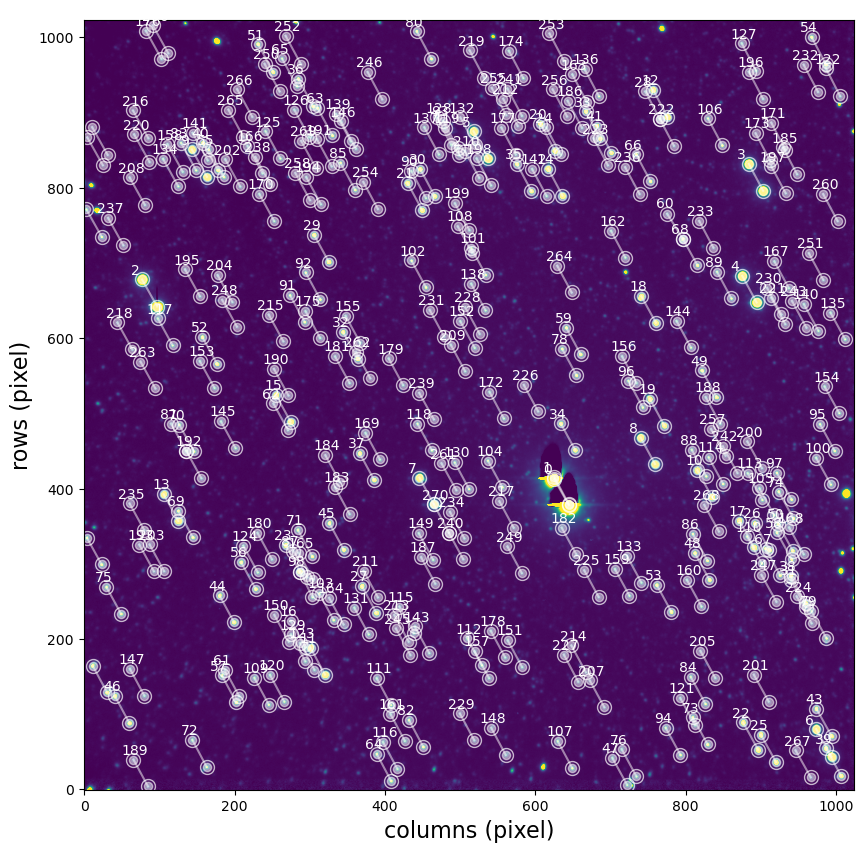

In [7]:
s4plt.plot_sci_polar_frame(polar_stack_example)

Now print one of the catalogs to see its contents

In [8]:
catalog = 'CATALOG_POL_N_AP010'
pd.DataFrame(hdul[catalog].data)

,SRCINDEX,RA,DEC,X,Y,FWHMX,FWHMY,MAG,EMAG,SKYMAG,ESKYMAG,APER,FLAG
0,0,258.125013,-24.248759,644.727086,377.797824,11.774100,11.774100,-13.191780,NaN,-9.646301,0.001489,10,0
1,1,258.124984,-24.248511,644.316363,379.441663,11.774100,11.774100,-13.169039,NaN,-9.645611,0.001506,10,0
2,2,258.181684,-24.224283,97.031324,642.058788,4.765597,4.765597,-11.781180,0.000937,-9.564526,0.000905,10,0
3,3,258.098786,-24.209229,902.915076,796.106801,4.216397,4.216397,-11.390030,0.001155,-9.577820,0.000906,10,0
4,4,258.099536,-24.223196,894.303509,647.521579,4.203418,4.203418,-11.372614,0.001167,-9.590850,0.000891,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,266,258.168907,-24.200461,223.521658,894.473010,3.665075,3.665075,-5.481222,0.112758,-9.556262,0.000856,10,0
267,267,258.091624,-24.282294,966.236852,16.072010,5.378430,5.378430,-6.087271,0.070110,-9.587486,0.001274,10,0
268,268,258.104442,-24.251796,844.141376,342.916044,4770.230553,4770.230553,-6.862904,0.033283,-9.606210,0.000891,10,0
269,269,258.160078,-24.206837,308.235289,826.215451,3.145817,3.145817,-6.216703,0.058491,-9.564968,0.000915,10,0


Below we select the source with its index number assigned as the main target to be analyzed. Then we select other stars as comparisons for differential photometry. All indices are displayed in the image above.  

After selecting the stars we use the function `s4plt.plot_light_curve` to produce plots of the lightcurve data.

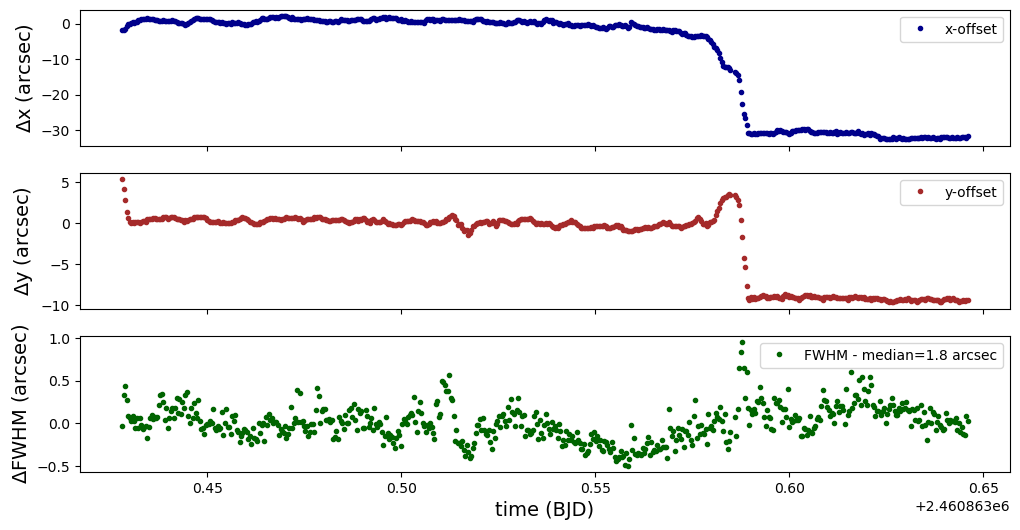

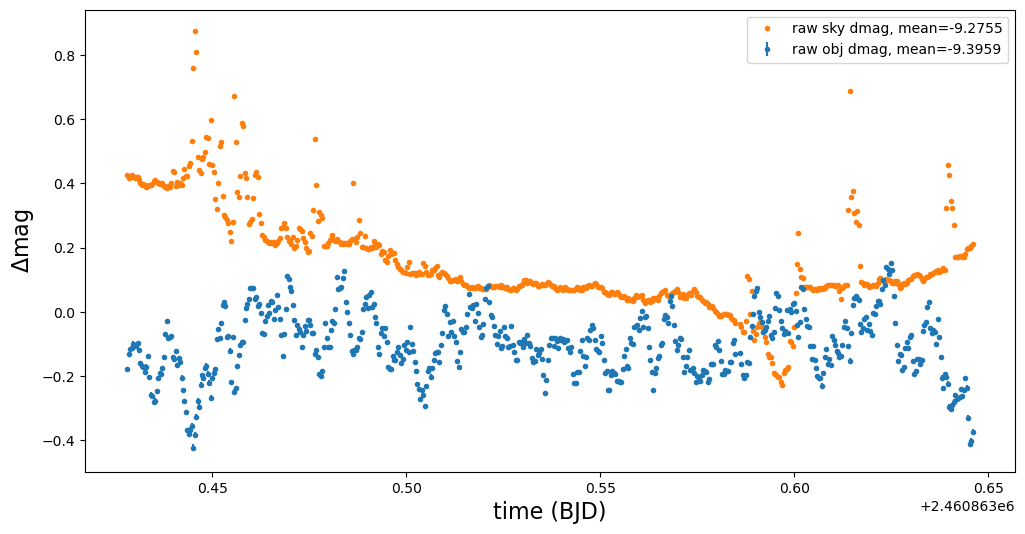

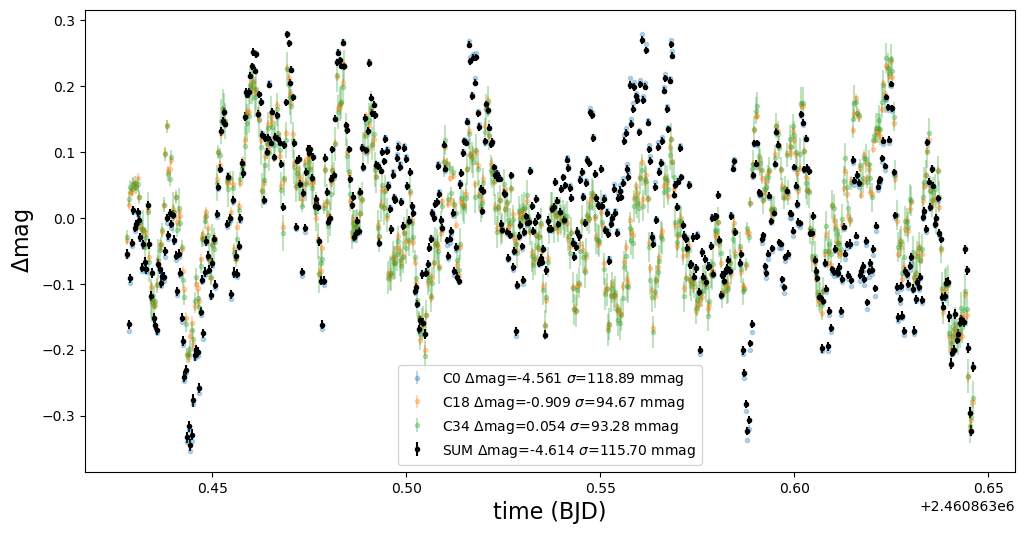

       TIME                x          ... magsum_err       diffmagsum     
------------------ ------------------ ... ---------- ---------------------
 2460863.428086052 375.94451149188023 ...        nan  -0.05494290325834594
 2460863.428463247 375.44451149188023 ...        nan  -0.16156883593084093
 2460863.428840199 376.69451149188023 ...        nan  -0.09191411647737358
 2460863.429217915 379.19451149188023 ...        nan -0.038157174775856895
 2460863.429595654 380.44451149188023 ...        nan  0.011658663817935455
 2460863.429972097 380.69451149188023 ...        nan -0.015202506775536584
 2460863.430349165 381.69451149188023 ...        nan  -0.00965129752476468
               ...                ... ...        ...                   ...
  2460863.64373729 284.69451149188023 ...        nan  -0.15831002770908587
 2460863.644115827 284.94451149188023 ...        nan  -0.04793971208058334
 2460863.644492848 285.44451149188023 ...        nan  -0.07945737764891359
2460863.6448721257 285.94

In [9]:
catalog = 'CATALOG_PHOT_AP010'
target=37
comps=[0,18,34]

lc = s4plt.plot_light_curve(phot_lightcurve_example, target=target, comps=comps, nsig=10,
                            plot_coords=True, plot_rawmags=True, plot_sum=True,
                            plot_comps=True, catalog_name=catalog)

print(lc)

Now we open a polarimetry FITS product and print its basic information

In [10]:
polar = fits.open(polar_example)
polar.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250706/sparc4acs4/20250706_s4c4_Gain2_1.0_Conventional_2_V2400Oph_POLAR_L4_polar.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    3483   ()      
  1  POLARIMETRY_AP005    1 BinTableHDU   4690   271R x 2339C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D

Below we print one of the catalog extensions

In [11]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data)

ValueError: Big-endian buffer not supported on little-endian compiler

ValueError: Big-endian buffer not supported on little-endian compiler

Then we can print all column names to check the data available in each catalog

In [12]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data).columns

Index(['APERINDEX', 'APER', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2',
       'FWHM',
       ...
       'FE0573', 'EFE0573', 'FO0574', 'EFO0574', 'FE0574', 'EFE0574', 'FO0575',
       'EFO0575', 'FE0575', 'EFE0575'],
      dtype='object', length=2339)

Finally, we can select the source of interest and then we get the polarimetry results using the function `get_polarimetry_results` from `sparc4.pipeline_lib` library:

2025-11-03 12:12:19,717 astropop - INFO - Normalization disabled.  [__init__]


2025-11-03 12:12:19,717 | INFO | Normalization disabled.


/home/fernando/anaconda3/lib/python3.12/site-packages/astropop/math/_deriv.py:29: RuntimeWarning: invalid value encountered in log
  return np.log(x)*np.power(x, y)
2025-11-03 12:12:19,744 root - INFO - Source index: i=37   [pipeline_lib]


2025-11-03 12:12:19,744 | INFO | Source index: i=37 


2025-11-03 12:12:19,745 root - INFO - Source RA=258.1516891677765 Dec=-24.245727896367686 mag=-16.3230+-0.0005  [pipeline_lib]


...

2025-11-03 12:12:20,033 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-03 12:12:20,263 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-03 12:12:20,263 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-03 12:12:20,270 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-03 12:12:20,270 | INFO | Substituting symbol \perp from STIXGeneral


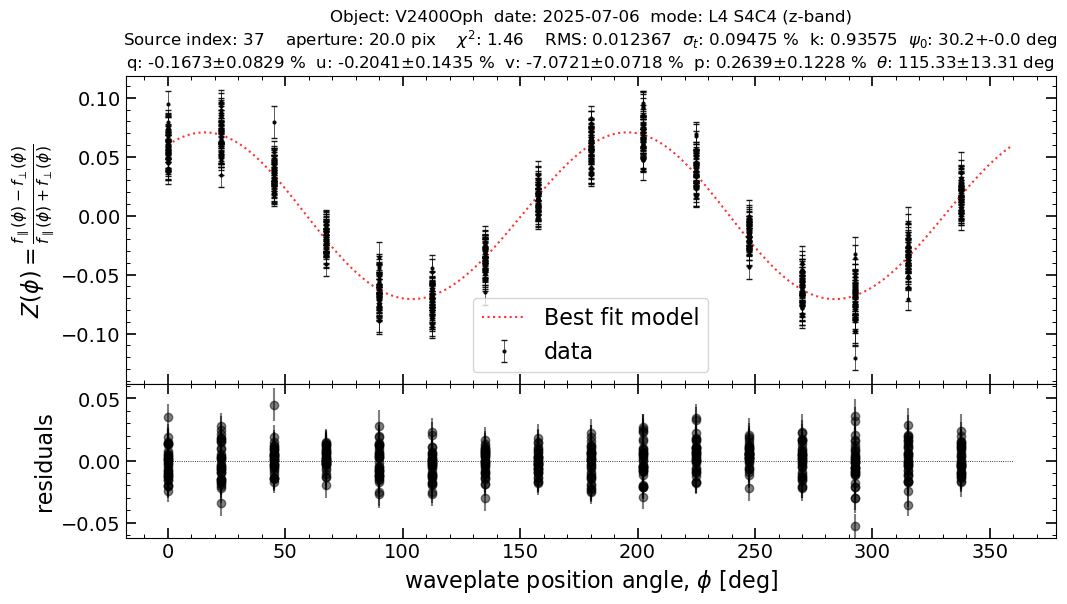

In [13]:
source_index = target

pol_results = s4pipelib.get_polarimetry_results(polar_example,
                                                source_index=source_index,
                                                min_aperture=5,
                                                max_aperture=21,
                                                plot=True,
                                                verbose=True)

Below we print all variables names for the measurements available in the polar product

In [14]:
for key in pol_results.keys():
    print(key, ":", pol_results[key])

POLAR_PRODUCT : /media/fernando/KINGSTON/Doutorado/2025/reduced/20250706/sparc4acs4/20250706_s4c4_Gain2_1.0_Conventional_2_V2400Oph_POLAR_L4_polar.fits
SOURCE_INDEX : 37
POLARIMETRY_SUCCESS : True
APERTURE_INDEX : 6
APERTURE_RADIUS : 20.0
NEXPS : 576
MAG : -16.3230+-0.0005
RA : 258.1516891677765
DEC : -24.245727896367686
FWHM : 3.8007525706706478
X1 : 366.34587233615883
Y1 : 446.94941285439745
X2 : 385.54315064760164
Y2 : 411.6720279621988
WAVEPLATE_ANGLES : [  0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5   0.   22.5  45.   67.5  90.  112.5 135.  157.5
 180.  202.5 225.  247.5 270.  292.5 315.  337.5   0.   22.5  45.   67.5
  90.  112.5 135.  157.5 180.  202.5 225.  247.5 270.  292.5 315.  337.5
   0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5   0.   22.5  45.   67.5  90.  112.5 135.  157.5
 180.  202.5 225.  247.5 270.  292.5 315.  337.5   0.   22.5  45.   67.5
  90.  112.5 135.  157.5 1

And below we show a simple example how to get one of these measurements out. For instance, we're getting the total polarization and the polarization angle. 

In [15]:
p = pol_results["P"]*100
pa = pol_results["THETA"]
print("Polarization: {} %  Angle of polarization: {} deg".format(p,pa) )

Polarization: 0.3+-0.1 %  Angle of polarization: 120+-10 deg deg


Finally, we show below an example of a polarimetric time series product. 

In [16]:
polar_ts = fits.open(polar_time_series_example)
pd.DataFrame(polar_ts[1].data)

ValueError: Big-endian buffer not supported on little-endian compiler

ValueError: Big-endian buffer not supported on little-endian compiler

In [17]:
pd.DataFrame(polar_ts[1].data).columns

Index(['TIME', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2', 'FWHM', 'MAG',
       'EMAG', 'Q', 'EQ', 'U', 'EU', 'V', 'EV', 'P', 'EP', 'THETA', 'ETHETA',
       'K', 'EK', 'ZERO', 'EZERO', 'NOBS', 'NPAR', 'CHI2', 'RMS', 'TSIGMA'],
      dtype='object')

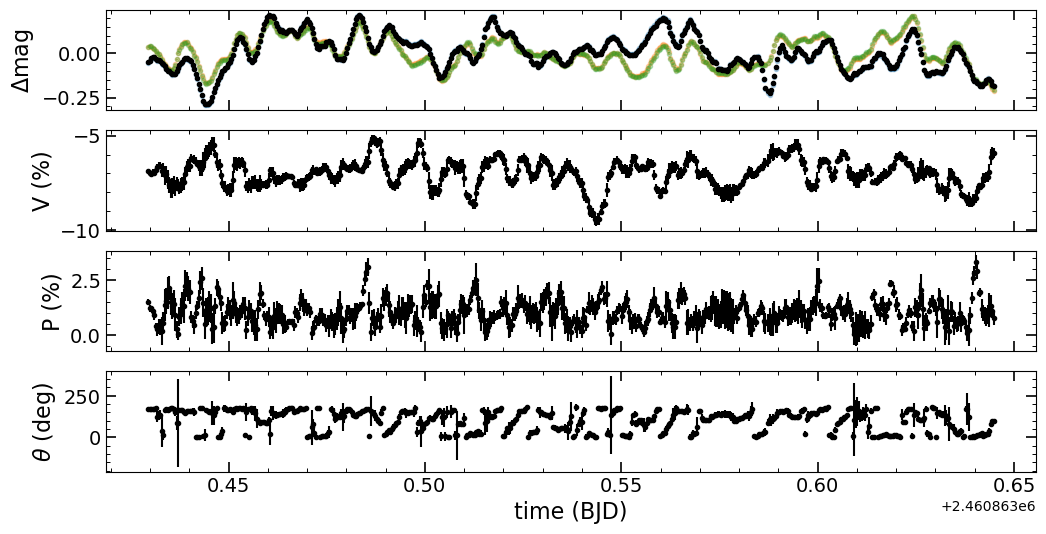

diffmag_C00000,diffmag_err_C00000,diffmag_C00001,diffmag_err_C00001,diffmag_C00002,diffmag_err_C00002,TIME,x1,y1,x2,y2,fwhm,mag,mag_err,magsum,magsum_err,diffmagsum,polarization_1,polarization_1_err,polarization_2,polarization_2_err
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-0.052254049800868785,nan,0.03416979429987421,0.0026628889574008955,0.03536769947325169,0.0038016898343753484,2460863.429579765,366.34587233615883,446.94941285439745,385.54315064760164,411.6720279621988,4.016759970594725,-11.635959440486221,0.0023878274696900893,-16.294400781890793,nan,-0.047841778491653386,0.015092388233412657,0.0012996526921675137,167.65724892744856,2.4628353326944654
-0.0461239718353994,nan,0.04195107941177589,0.0026478943789641374,0.04266063985721402,0.003785866101331089,2460863.4299576953,365.84587233615883,443.19941285439745,385.04315064760164,407.9220279621988,4.016759970594725,-11.643138543059962,0.0023707047207355853,-16.29538458651616,nan,-0.04164648054327991,0.012137489420907034,0.001454348187508296,169.0878680577673,3.4269325986880177
-0.02792044501843627,nan,0.0378372133342193,0.0026510828147298287,0.038462386226242984,0.003789033527160163,2460863.430334988,367.09587233615883,439.19941285439745,386.29315064760164,403.9220279621988,3.895902920847581,-11.63970367447389,0.0023750478737439027,-16.27472079907749,nan,-0.024417561690679435,0.012154093488310156,0.0013144313493245556,167.48676092206924,3.093010320090026
-0.025003213972215832,nan,0.030999877546420862,0.002659585676435403,0.030612154638419042,0.003791597612606872,2460863.430712953,369.59587233615883,434.94941285439745,388.79315064760164,399.6720279621988,3.8837722870397355,-11.633202955879867,0.0023850641600286757,-16.265747538708563,nan,-0.02194501991577802,0.010823939568913424,0.001992792225838086,172.95394633292383,5.265537311632521
-0.024774687150472374,nan,0.023768890033036172,0.002669687465802225,0.02305010816917452,0.005139856027097784,2460863.4310904955,370.84587233615883,432.69941285439745,390.04315064760164,397.4220279621988,3.8684130072346594,-11.626099850716319,0.0023965386079274078,-16.258752850047667,nan,-0.02205343641842994,0.00904713814463569,0.002256653791847874,167.66898721922666,7.133780585092206
-0.034337365608950066,nan,0.01214241174514008,0.002686286903846864,0.011183713784337357,0.006209288077995698,2460863.431467071,371.09587233615883,431.44941285439745,390.29315064760164,396.1720279621988,3.861890612265836,-11.615095277177245,0.0024154912866924303,-16.257406511986122,nan,-0.031711671895958915,0.00398399835801576,0.001428146646250132,175.0585262248515,10.252261776306735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
-0.17029971361220042,nan,-0.1697552772519355,0.0027061499509515377,-0.16460126761196037,0.008901267216451823,2460863.642590443,275.34587233615883,403.69941285439745,294.54315064760164,368.4220279621988,3.83100649930414,-11.49256294013294,0.0024916276640756757,-16.272854712243966,nan,-0.16969220919810724,0.009027847884561938,0.0037417117476112533,12.440195721815222,11.853650764838346
-0.1508029759622307,nan,-0.16212934740102192,0.002677801127460601,-0.1572444183181254,0.008847609105933397,2460863.642968268,275.59587233615883,402.94941285439745,294.79315064760164,367.6720279621988,3.8231944967026243,-11.501923080745515,0.002463067312966095,-16.26327785438134,nan,-0.15075521072290599,0.008292919936849951,0.003993659236731453,20.089344924335904,13.77303230228764


In [18]:
s4plt.plot_polar_time_series(polar_time_series_example, 
                             target=target, 
                             comps=comps, 
                             plot_total_polarization=True, 
                             plot_polarization_angle=True)